
# 15-point full-data CI diagnostic notebook

This notebook reads the results from:

`C:\Users\yangy\26 spring\with reference\15 points\results`

and performs **double-check diagnostics** for the 15-point Scheme-A experiment.

It will:

1. Load all `hits_repXXX_A15_J50.npy` / `pointwise_hits_repXXX_A15.csv`
2. Aggregate **pointwise coverage** over replications for each alpha
3. Plot all alpha coverage curves against the nominal 95% line
4. Compute pointwise \(\alpha^*(x)\) using  
   **max alpha such that coverage(alpha, x) >= 0.95**
5. Build the final calibrated coverage curve after pointwise alpha selection
6. Report which points are still undercovered after calibration
7. Save summary CSV files and plots back into the same results folder

Because your saved `hits` are already indicators against the true \(f_0\), this notebook is effectively a **direct diagnostic of the final CI mechanism**.


In [1]:

# --- user settings ---
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = r"C:\Users\yangy\26 spring\with reference\15 points\results"
TARGET_COVERAGE = 0.95

# If you want to subset reps for testing, change this:
REPS = list(range(100))

FIG_DPI = 160


In [2]:

def rep_hits_path(rep_id: int) -> str:
    patt = os.path.join(RESULTS_DIR, f"hits_rep{rep_id:03d}_A15_J*.npy")
    hits = glob.glob(patt)
    if not hits:
        raise FileNotFoundError(f"No hits file found for rep {rep_id:03d}: {patt}")
    hits.sort()
    return hits[0]

def rep_csv_path(rep_id: int) -> str:
    patt = os.path.join(RESULTS_DIR, f"pointwise_hits_rep{rep_id:03d}_A15.csv")
    hits = glob.glob(patt)
    if not hits:
        raise FileNotFoundError(f"No pointwise csv found for rep {rep_id:03d}: {patt}")
    hits.sort()
    return hits[0]

def rep_meta_path(rep_id: int) -> str:
    patt = os.path.join(RESULTS_DIR, f"meta_rep{rep_id:03d}.json")
    hits = glob.glob(patt)
    if not hits:
        raise FileNotFoundError(f"No meta json found for rep {rep_id:03d}: {patt}")
    return hits[0]

print(rep_hits_path(42))
print(rep_csv_path(65))
print(rep_meta_path(1))


C:\Users\yangy\26 spring\with reference\15 points\results\hits_rep042_A15_J50.npy
C:\Users\yangy\26 spring\with reference\15 points\results\pointwise_hits_rep065_A15.csv
C:\Users\yangy\26 spring\with reference\15 points\results\meta_rep001.json


In [3]:

import json

ref_rep = REPS[0]
with open(rep_meta_path(ref_rep), "r", encoding="utf-8") as f:
    meta0 = json.load(f)

alphas = np.array(meta0["alphas"], dtype=float)
print("alphas =", alphas)

df0 = pd.read_csv(rep_csv_path(ref_rep))
x_grid = df0["x"].to_numpy()
print("x grid length:", len(x_grid))

A = len(alphas)
J = len(x_grid)
print("A, J =", A, J)


alphas = [0.06666667 0.13333333 0.2        0.26666667 0.33333333 0.4
 0.46666667 0.53333333 0.6        0.66666667 0.73333333 0.8
 0.86666667 0.93333333 1.        ]
x grid length: 50
A, J = 15 50



## 1) Load and aggregate hits over replications
Each saved `hits_repXXX_A15_J50.npy` is shape `[A, J]`, where each entry is a 0/1 hit indicator:
\[
\mathbf{1}\{f_0(x_j) \in CI_\alpha(x_j)\}.
\]

Averaging these over replications gives empirical pointwise coverage for each alpha.


In [4]:

hits_all = []
missing = []

for rep in REPS:
    try:
        arr = np.load(rep_hits_path(rep))
        if arr.shape != (A, J):
            raise ValueError(f"rep {rep}: expected {(A,J)}, got {arr.shape}")
        hits_all.append(arr)
    except Exception as e:
        print(f"[skip rep {rep:03d}] {e}")
        missing.append(rep)

hits_all = np.stack(hits_all, axis=0)   # [R, A, J]
R_eff = hits_all.shape[0]

print("loaded reps:", R_eff)
print("missing reps:", missing[:10], "..." if len(missing) > 10 else "")

coverage_alpha_x = hits_all.mean(axis=0)   # [A, J]
coverage_alpha_mean = coverage_alpha_x.mean(axis=1)
coverage_x_best_possible = coverage_alpha_x.max(axis=0)


loaded reps: 100
missing reps: [] 



## 2) Plot pointwise coverage curves for all alphas


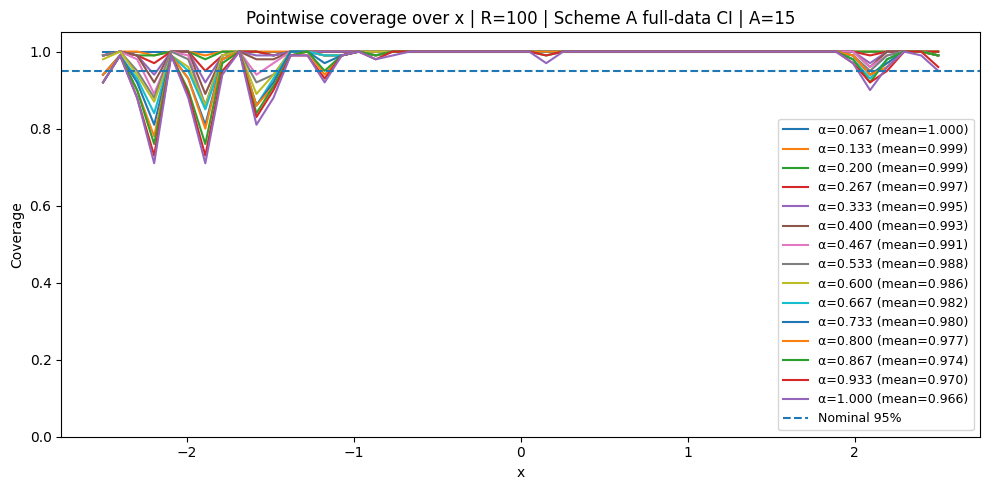

Saved: C:\Users\yangy\26 spring\with reference\15 points\results\diag_all_alpha_pointwise_coverage_A15.png


In [5]:

plt.figure(figsize=(10,5))
for a_idx, alpha in enumerate(alphas):
    plt.plot(x_grid, coverage_alpha_x[a_idx], label=f"α={alpha:.3f} (mean={coverage_alpha_mean[a_idx]:.3f})")
plt.axhline(TARGET_COVERAGE, linestyle="--", label="Nominal 95%")
plt.ylim(0.0, 1.05)
plt.xlabel("x")
plt.ylabel("Coverage")
plt.title(f"Pointwise coverage over x | R={R_eff} | Scheme A full-data CI | A=15")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()

plot_all_path = os.path.join(RESULTS_DIR, "diag_all_alpha_pointwise_coverage_A15.png")
plt.savefig(plot_all_path, dpi=FIG_DPI)
plt.show()

print("Saved:", plot_all_path)



## 3) Choose pointwise α*(x) using max α such that coverage >= 0.95
This uses the **aggregated coverage curves**, not per-rep selection.

Rule:
\[
\alpha^*(x_j)=\max\{\alpha:\widehat{\mathrm{Cov}}(\alpha,x_j)\ge 0.95\}.
\]
If no alpha satisfies the threshold, choose the smallest alpha.


In [6]:

def alpha_star_max_alpha_ge(coverage_vec, alphas, target=0.95):
    order = np.argsort(-alphas)
    for idx in order:
        if coverage_vec[idx] >= target - 1e-12:
            return alphas[idx], coverage_vec[idx], idx
    idx_min = np.argmin(alphas)
    return alphas[idx_min], coverage_vec[idx_min], idx_min

alpha_star = np.zeros(J, dtype=float)
alpha_star_cov = np.zeros(J, dtype=float)
alpha_star_idx = np.zeros(J, dtype=int)

for j in range(J):
    a, c, idx = alpha_star_max_alpha_ge(coverage_alpha_x[:, j], alphas, target=TARGET_COVERAGE)
    alpha_star[j] = a
    alpha_star_cov[j] = c
    alpha_star_idx[j] = idx

alpha_star_df = pd.DataFrame({
    "x": x_grid,
    "alpha_star": alpha_star,
    "coverage_at_alpha_star": alpha_star_cov,
    "best_possible_coverage_over_all_alpha": coverage_x_best_possible,
})
display(alpha_star_df.head())
print(pd.Series(alpha_star).value_counts().sort_index())


,x,alpha_star,coverage_at_alpha_star,best_possible_coverage_over_all_alpha
0,-2.500000,0.600000,0.98,1.0
1,-2.397959,1.000000,0.99,1.0
2,-2.295918,0.533333,0.95,1.0
3,-2.193878,0.266667,0.97,1.0
4,-2.091837,1.000000,0.99,1.0


0.266667     2
0.400000     1
0.466667     1
0.533333     2
0.600000     1
0.666667     1
0.866667     1
0.933333     1
1.000000    40
Name: count, dtype: int64



## 4) Final calibrated pointwise coverage after α*(x)
Because the raw saved arrays are already hits vs \(f_0\), we can directly assemble the final calibrated curve by selecting, at each x, the row corresponding to α*(x).


In [7]:

final_calibrated_hits = np.zeros((R_eff, J), dtype=np.int8)
for r in range(R_eff):
    for j in range(J):
        final_calibrated_hits[r, j] = hits_all[r, alpha_star_idx[j], j]

final_calibrated_coverage = final_calibrated_hits.mean(axis=0)

final_df = pd.DataFrame({
    "x": x_grid,
    "alpha_star": alpha_star,
    "coverage_after_alpha_star": final_calibrated_coverage,
    "coverage_at_alpha_star_from_aggregated_curves": alpha_star_cov,
    "best_possible_coverage_over_all_alpha": coverage_x_best_possible,
})
display(final_df.head())


,x,alpha_star,coverage_after_alpha_star,coverage_at_alpha_star_from_aggregated_curves,best_possible_coverage_over_all_alpha
0,-2.500000,0.600000,0.98,0.98,1.0
1,-2.397959,1.000000,0.99,0.99,1.0
2,-2.295918,0.533333,0.95,0.95,1.0
3,-2.193878,0.266667,0.97,0.97,1.0
4,-2.091837,1.000000,0.99,0.99,1.0


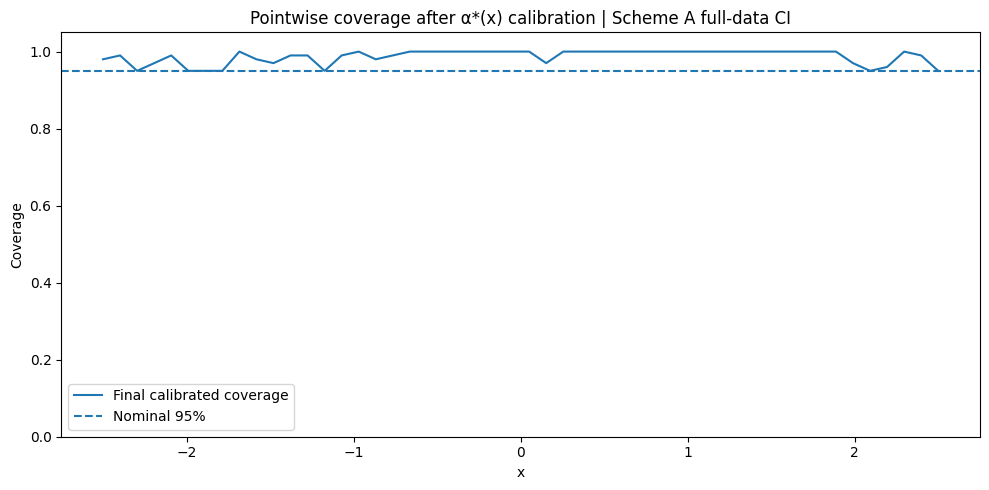

Saved: C:\Users\yangy\26 spring\with reference\15 points\results\diag_final_calibrated_coverage_A15.png


In [8]:

plt.figure(figsize=(10,5))
plt.plot(x_grid, final_calibrated_coverage, label="Final calibrated coverage")
plt.axhline(TARGET_COVERAGE, linestyle="--", label="Nominal 95%")
plt.ylim(0.0, 1.05)
plt.xlabel("x")
plt.ylabel("Coverage")
plt.title("Pointwise coverage after α*(x) calibration | Scheme A full-data CI")
plt.legend()
plt.tight_layout()

plot_final_path = os.path.join(RESULTS_DIR, "diag_final_calibrated_coverage_A15.png")
plt.savefig(plot_final_path, dpi=FIG_DPI)
plt.show()

print("Saved:", plot_final_path)



## 5) Diagnose persistent shortfalls

Three useful diagnostics:

1. `coverage_after_alpha_star < 0.95`  
   Final calibrated shortfalls

2. `best_possible_coverage_over_all_alpha < 0.95`  
   Even the best alpha cannot reach 0.95 at that point  
   → suggests a limitation of the CI mechanism itself

3. `best_possible_coverage_over_all_alpha >= 0.95` but final still < 0.95  
   → suggests finite-sample / aggregate-vs-realized selection mismatch


In [9]:

under_idx = np.where(final_calibrated_coverage < TARGET_COVERAGE - 1e-12)[0]
under_df = final_df.iloc[under_idx].copy()

if len(under_df) == 0:
    print("No final undercovered points.")
else:
    under_df["can_any_alpha_reach_095"] = under_df["best_possible_coverage_over_all_alpha"] >= TARGET_COVERAGE - 1e-12
    display(under_df)

print("Number of final undercovered points:", len(under_df))


No final undercovered points.
Number of final undercovered points: 0


In [10]:

if len(under_idx) > 0:
    rows = []
    for j in under_idx:
        row = {"x": x_grid[j], "alpha_star": alpha_star[j], "final_coverage": final_calibrated_coverage[j]}
        for a_idx, alpha in enumerate(alphas):
            row[f"cov_alpha_{alpha:.3f}"] = coverage_alpha_x[a_idx, j]
        rows.append(row)
    under_detail_df = pd.DataFrame(rows)
    display(under_detail_df)
else:
    under_detail_df = pd.DataFrame()



## 6) Save summary CSV files


In [11]:

alpha_star_csv = os.path.join(RESULTS_DIR, "alpha_star_x_A15_schemeA.csv")
final_csv = os.path.join(RESULTS_DIR, "coverage_after_alpha_star_A15_schemeA.csv")
all_alpha_csv = os.path.join(RESULTS_DIR, "mean_pointwise_coverage_all_alpha_A15_schemeA.csv")
under_csv = os.path.join(RESULTS_DIR, "undercovered_points_after_alpha_star_A15_schemeA.csv")

alpha_star_df.to_csv(alpha_star_csv, index=False)
final_df.to_csv(final_csv, index=False)

all_alpha_out = {"x": x_grid}
for a_idx, alpha in enumerate(alphas):
    all_alpha_out[f"alpha_{alpha:.6f}"] = coverage_alpha_x[a_idx]
pd.DataFrame(all_alpha_out).to_csv(all_alpha_csv, index=False)

under_df.to_csv(under_csv, index=False)

print("Saved:")
print(alpha_star_csv)
print(final_csv)
print(all_alpha_csv)
print(under_csv)


Saved:
C:\Users\yangy\26 spring\with reference\15 points\results\alpha_star_x_A15_schemeA.csv
C:\Users\yangy\26 spring\with reference\15 points\results\coverage_after_alpha_star_A15_schemeA.csv
C:\Users\yangy\26 spring\with reference\15 points\results\mean_pointwise_coverage_all_alpha_A15_schemeA.csv
C:\Users\yangy\26 spring\with reference\15 points\results\undercovered_points_after_alpha_star_A15_schemeA.csv



## 7) Optional: zoom on left-side region


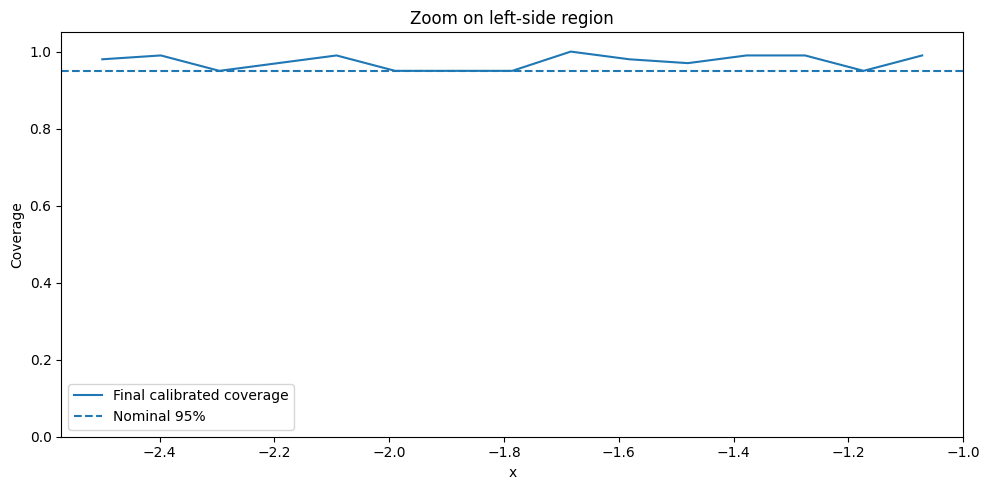

Saved: C:\Users\yangy\26 spring\with reference\15 points\results\diag_left_zoom_final_calibrated_coverage_A15.png


In [12]:

mask_left = x_grid < -1.0

plt.figure(figsize=(10,5))
plt.plot(x_grid[mask_left], final_calibrated_coverage[mask_left], label="Final calibrated coverage")
plt.axhline(TARGET_COVERAGE, linestyle="--", label="Nominal 95%")
plt.ylim(0.0, 1.05)
plt.xlabel("x")
plt.ylabel("Coverage")
plt.title("Zoom on left-side region")
plt.legend()
plt.tight_layout()

zoom_path = os.path.join(RESULTS_DIR, "diag_left_zoom_final_calibrated_coverage_A15.png")
plt.savefig(zoom_path, dpi=FIG_DPI)
plt.show()

print("Saved:", zoom_path)
